In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df=pd.read_csv("/content/Attrition.csv")

In [4]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# Check quality

In [5]:
df.isnull().sum()
df.isnull().sum() / len(df) * 100



,0
Age,0.0
Attrition,0.0
BusinessTravel,0.0
DailyRate,0.0
Department,0.0
DistanceFromHome,0.0
Education,0.0
EducationField,0.0
EmployeeCount,0.0
EmployeeNumber,0.0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df.dropna(inplace=True)

#1- What is effect of age on attrition ?

In [9]:
df.groupby('Attrition')['Age'].mean()
# كلما قل العمر زاد معدل ترك العمل
#عدم وجود استقرار وظيفي لدى الاصغر سنا

,Age
Attrition,
No,37.561233
Yes,33.607595


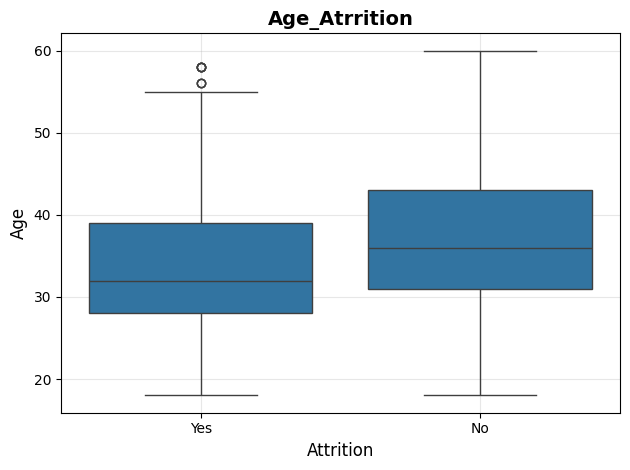

In [10]:
sns.boxplot(x='Attrition',y='Age',data=df)
plt.title('Age_Atrrition', fontsize=14, fontweight='bold')
plt.ylabel('Age', fontsize=12)
plt.xlabel('Attrition', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

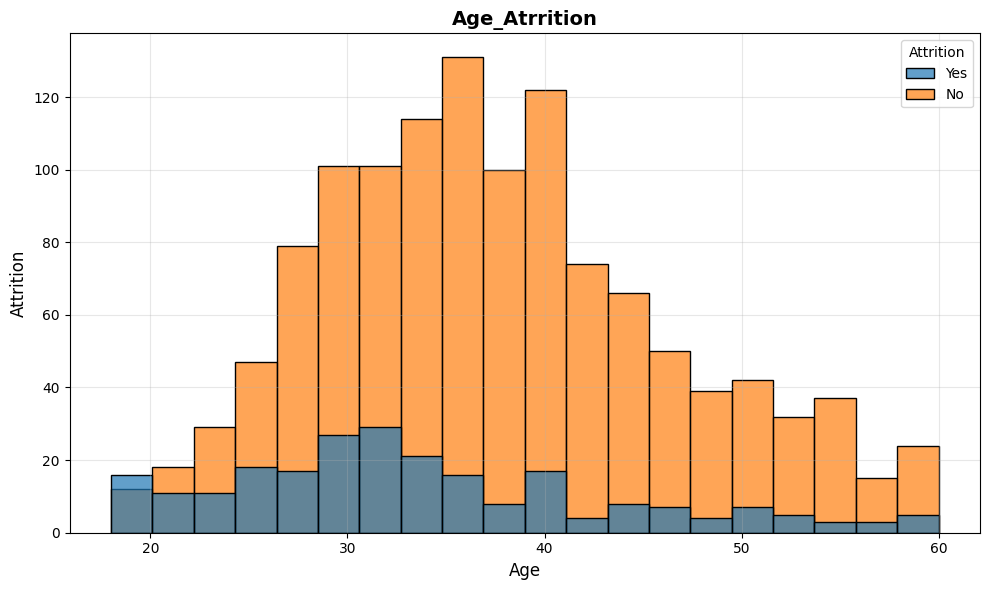

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df,x='Age',hue='Attrition',bins=20,color=['skyblue','lightgreen'], alpha=0.7, edgecolor='black')
plt.title('Age_Atrrition', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Attrition', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2- Is income the main factor towards employee atrition ?

In [13]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [14]:
df.groupby('Attrition')['MonthlyIncome'].mean()
#  الموظفين اصحاب المرتبات الاقل يتركون العمل اكثر من غيرهم

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


In [15]:
df.groupby(['MonthlyIncome','Attrition']).size().unstack(fill_value=0)

Attrition,No,Yes
MonthlyIncome,,
1009,0,1
1051,1,0
1052,1,0
1081,0,1
1091,0,1
...,...,...
19859,0,1
19926,1,0
19943,1,0


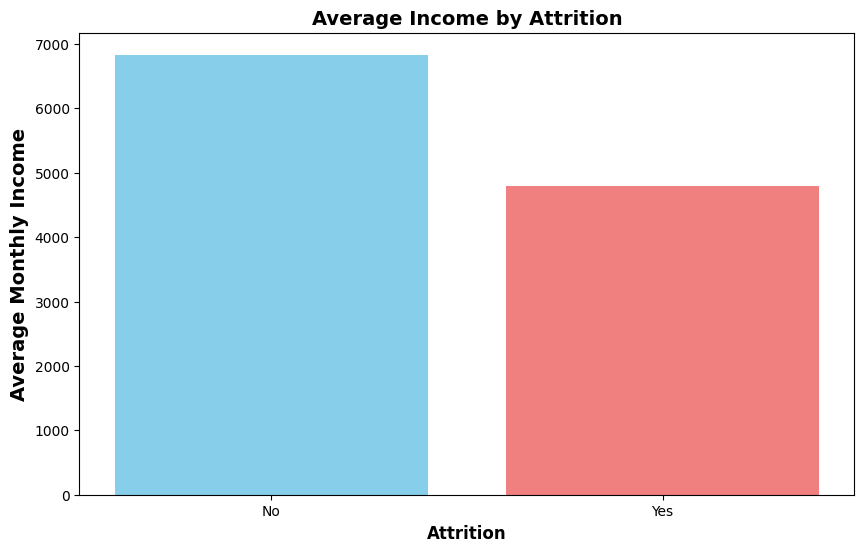

In [16]:
income_attrition = df.groupby("Attrition")["MonthlyIncome"].mean()
plt.figure(figsize=(10, 6))
plt.bar(income_attrition.index, income_attrition.values,width=0.8, color=['skyblue', 'lightcoral'])
plt.title("Average Income by Attrition",fontsize=14, fontweight='bold')
plt.xlabel("Attrition",fontsize=12,fontweight='bold')
plt.ylabel("Average Monthly Income", fontsize=14,fontweight='bold')
plt.xticks(rotation=0)
plt.show()

#3- Dose the department of work impact attrition ?

In [17]:
attrition_by_department=df.groupby('Department')['Attrition'].value_counts().unstack()
attrition_by_department

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


<Figure size 1000x600 with 0 Axes>

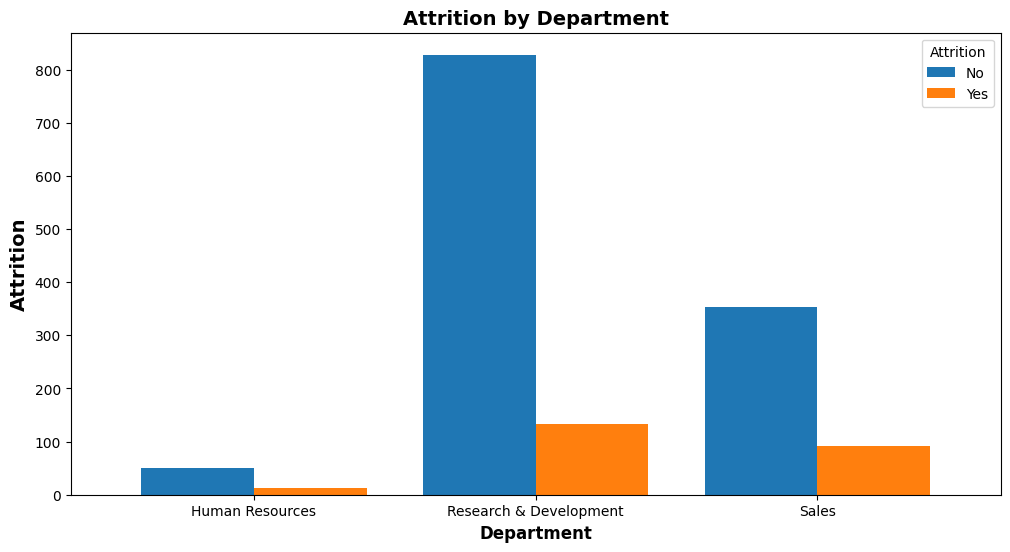

In [18]:
plt.figure(figsize=(10, 6))
attrition_by_department.plot(kind='bar',width=0.8, figsize=(12, 6))
plt.title("Attrition by Department",fontsize=14, fontweight='bold')
plt.xlabel("Department",fontsize=12,fontweight='bold')
plt.ylabel("Attrition", fontsize=14,fontweight='bold')
plt.xticks(rotation=0)
plt.show()
#قسم البحث و التطور اعلى نسبة في استقالة موظفيه

In [19]:
tree_data = df.groupby(['Department', 'Attrition']).size().reset_index(name='Employee_Count')
fig = px.treemap(
    data_frame=tree_data,
    path=['Department', 'Attrition'],
    values='Employee_Count',
    title='Attrition by Department'
)
fig.update_traces(textinfo='label+value')
fig.show()

#4- How does the environment satisfaction impact attrition?

In [20]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [21]:
environmentSatisfaction=df.groupby('EnvironmentSatisfaction')['Attrition'].value_counts().unstack()
environmentSatisfaction

Attrition,No,Yes
EnvironmentSatisfaction,,
1,212,72
2,244,43
3,391,62
4,386,60


<Figure size 1000x600 with 0 Axes>

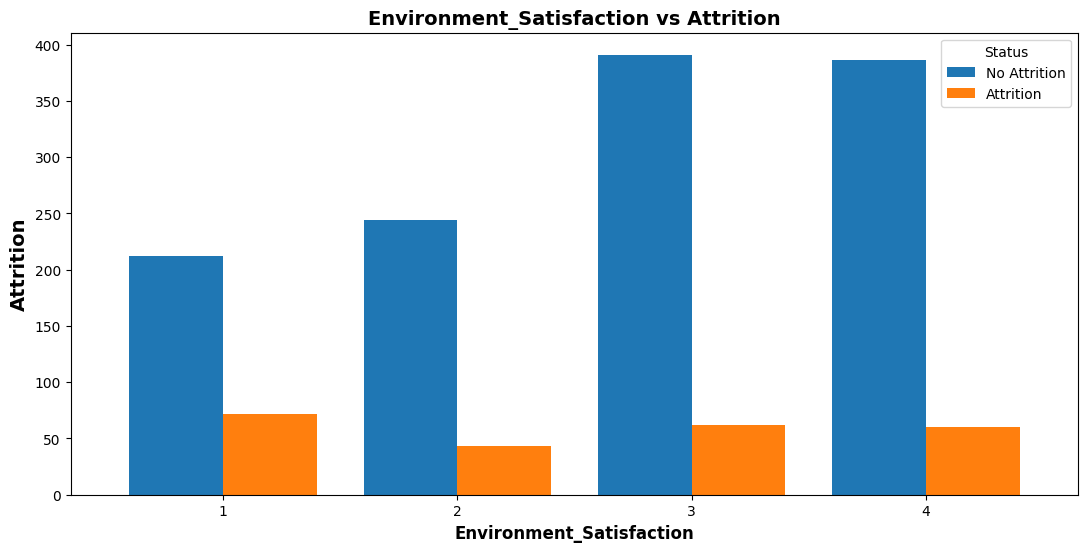

In [22]:
plt.figure(figsize=(10,6))
environmentSatisfaction.plot(kind='bar',width=0.8,figsize=(13,6))
plt.title("Environment_Satisfaction vs Attrition",fontsize=14, fontweight='bold')
plt.xlabel("Environment_Satisfaction",fontsize=12,fontweight='bold')
plt.ylabel("Attrition", fontsize=14,fontweight='bold')
plt.xticks(rotation=0)
plt.legend(['No Attrition', 'Attrition'], title='Status')
plt.show()
#كلما زاد الرضا البيئي عن الوظيفة قلت معدل الاستقاله

#5- How does self job satisfaction impact the Attrition ?

In [23]:
df.groupby('JobSatisfaction')['Attrition'].value_counts().unstack()
#كلما زاد الرضا الوظيفي عن الوظيفة زاد الاستقرار الوظيفي و الاستمرار في العمل

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [24]:
none_attrition=df[df['Attrition']=="No"]
attrition_by_job_satisfavtion=none_attrition['JobSatisfaction'].value_counts().sort_values()
attrition_by_job_satisfavtion


,count
JobSatisfaction,
1,223
2,234
3,369
4,407


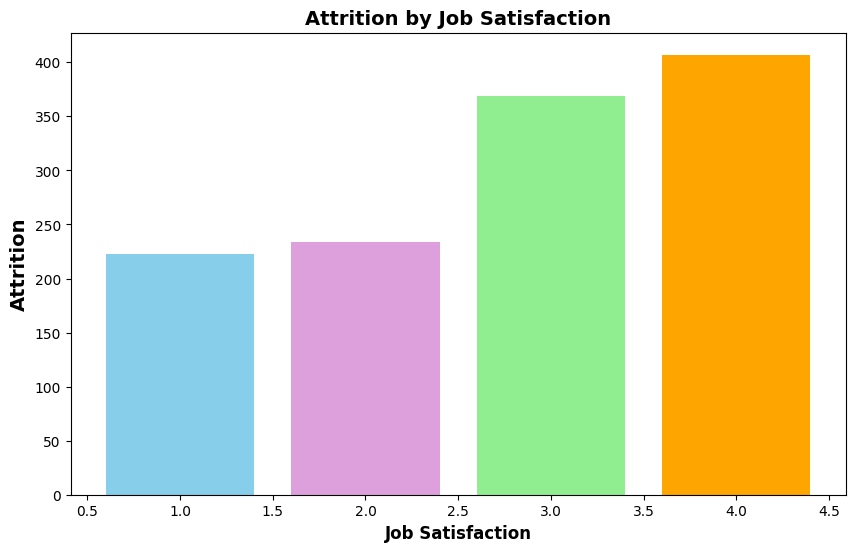

In [25]:
plt.figure(figsize=(10,6))
plt.bar(attrition_by_job_satisfavtion.index,attrition_by_job_satisfavtion.values, color=['skyblue', 'plum', 'lightgreen', 'orange'])
plt.title("Attrition by Job Satisfaction",fontsize=14, fontweight='bold')
plt.xlabel("Job Satisfaction",fontsize=12,fontweight='bold')
plt.ylabel("Attrition", fontsize=14,fontweight='bold')
plt.xticks(rotation=0)
plt.show()

#6- Does company stocks for employees impact attrition?

In [26]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [27]:
stock_level=df.groupby('StockOptionLevel')['Attrition'].value_counts().unstack().sort_values(by='StockOptionLevel',ascending=False)
stock_level

Attrition,No,Yes
StockOptionLevel,,
3,70,15
2,146,12
1,540,56
0,477,154


<Figure size 1000x600 with 0 Axes>

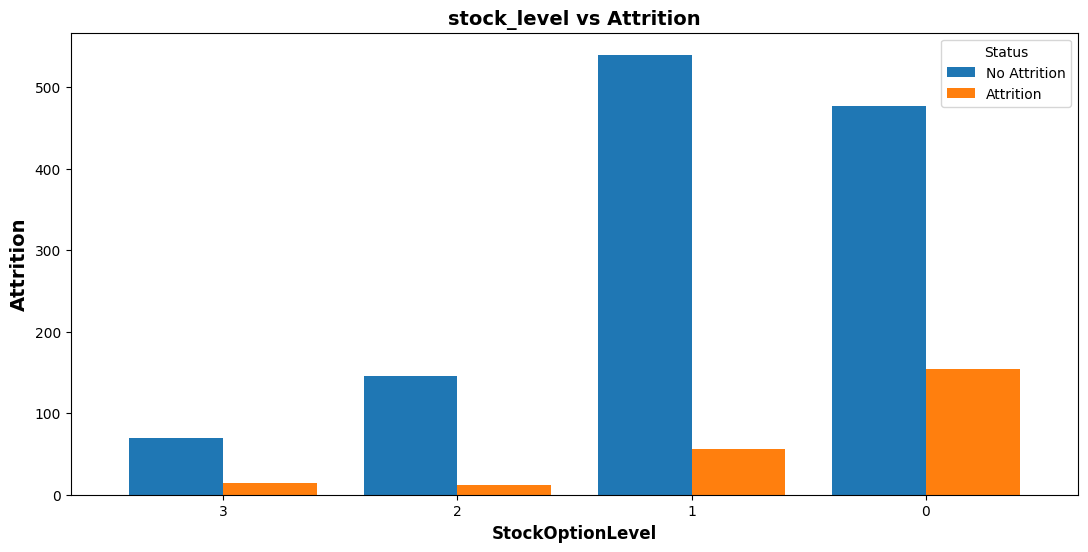

In [28]:
plt.figure(figsize=(10,6))
stock_level.plot(kind='bar',width=0.8,figsize=(13,6))
plt.title('stock_level vs Attrition',fontsize=14, fontweight='bold')
plt.xlabel("StockOptionLevel",fontsize=12,fontweight='bold')
plt.ylabel("Attrition", fontsize=14,fontweight='bold')
plt.xticks(rotation=0)
plt.legend(['No Attrition', 'Attrition'], title='Status')
plt.show()
#كلما قل مستوى خيارات الاسهم زاد معدل الاستمرار في العمل
#الموظفون الذين يملكون اسهم في الشركة اقل عرضه لترك العمل

In [29]:
attrition=df[df['Attrition']=="No"]
stock_level=attrition['StockOptionLevel'].value_counts().sort_values()
stock_level

,count
StockOptionLevel,
3,70
2,146
0,477
1,540


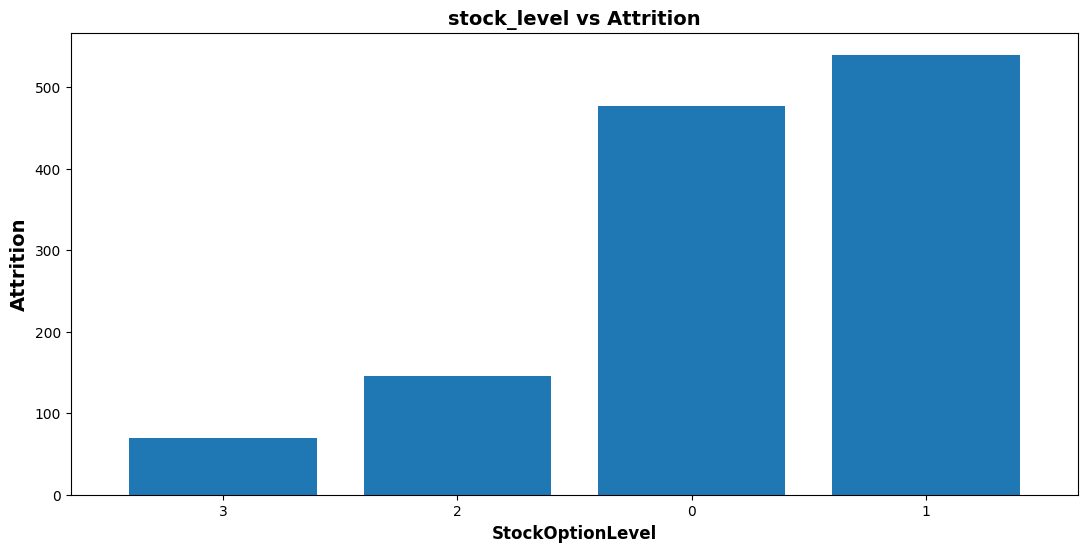

In [30]:
plt.figure(figsize=(10,6))
stock_level.plot(kind='bar',width=0.8,figsize=(13,6))
plt.title('stock_level vs Attrition',fontsize=14, fontweight='bold')
plt.xlabel("StockOptionLevel",fontsize=12,fontweight='bold')
plt.ylabel("Attrition", fontsize=14,fontweight='bold')
plt.xticks(rotation=0)
plt.show()
#كلما قل مستوى خيارات الاسهم زاد معدل الاستمرار في العمل
#الموظفون الذين يملكون اسهم في الشركة اقل عرضه لترك العمل

#7- How does Work Life Balance impact the overall attrition rates?

In [31]:
WorkLife_Balance=df.groupby('Attrition')['WorkLifeBalance'].value_counts().unstack()
WorkLife_Balance


WorkLifeBalance,1,2,3,4
Attrition,,,,
No,55,286,766,126
Yes,25,58,127,27


In [32]:
attrition_by_no=df[df['Attrition']=="No"]
attrition_by_no=attrition_by_no['WorkLifeBalance']
attrition_by_no


,WorkLifeBalance
1,3
3,3
4,3
5,2
6,2
...,...
1465,3
1466,3
1467,3
1468,2


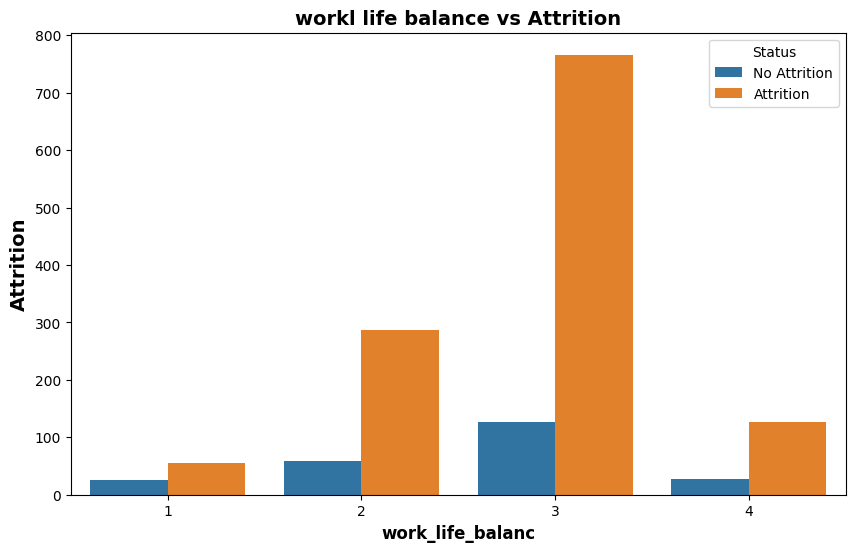

In [33]:
plt.figure(figsize=(10,6))
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df)
plt.title('workl life balance vs Attrition',fontsize=14, fontweight='bold')
plt.xlabel("work_life_balanc",fontsize=12,fontweight='bold')
plt.ylabel("Attrition", fontsize=14,fontweight='bold')
plt.xticks(rotation=0)
plt.legend(['No Attrition', 'Attrition'], title='Status')
plt.show()
#كلما زاد التوازن بين العمل و الحياة الاجتماعية زاد معدل الاستقرار الوظيفي

#8- How does work experience affect attrition?


In [34]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [35]:
df.groupby("Attrition")["TotalWorkingYears"].mean()
#كلما قلت سنوات الخبره زاد ترك العمل
#كلما زادت سنوات الخبره زاد الاستمرار في العمل

,TotalWorkingYears
Attrition,
No,11.862936
Yes,8.244726


In [36]:
px.box(data_frame=df,
       x='Attrition',
       y='TotalWorkingYears',
       title='Work exprience affect attrition',
       color='Attrition')

#9- How does work duration in current role impact Attrition?

In [37]:
df['YearsInCurrentRole']

,YearsInCurrentRole
0,4
1,7
2,0
3,7
4,2
...,...
1465,2
1466,7
1467,2
1468,6


In [38]:
df.groupby("Attrition")["YearsInCurrentRole"].mean()
#كلما زادت عدد السنوات في الوظيفه الواحده زاد الاستمرار في العمل

,YearsInCurrentRole
Attrition,
No,4.484185
Yes,2.902954


In [39]:
px.box(data_frame=df,
       x='Attrition',
       y='YearsInCurrentRole',
       title='Years in Current Role',
       color='Attrition')

#10- Does hike percentage impact Attrition?

In [40]:
salary_hike=df.groupby("Attrition")["PercentSalaryHike"].mean()
salary_hike
#زيادة الراتب السنوي غير مؤثره على معدل الاستقاله و ترك العمل

,PercentSalaryHike
Attrition,
No,15.231144
Yes,15.097046


#11- Are managers a reason of people resigning?

In [41]:
df['YearsWithCurrManager'].value_counts()

,count
YearsWithCurrManager,
2,344
0,263
7,216
3,142
8,107
4,98
1,76
9,64
5,31


In [42]:
attritions=df[df['Attrition']=="No"]
manegers=attritions["YearsWithCurrManager"].value_counts()
manegers

,count
YearsWithCurrManager,
2,294
7,185
0,178
3,123
8,97
4,87
1,65
9,58
5,27


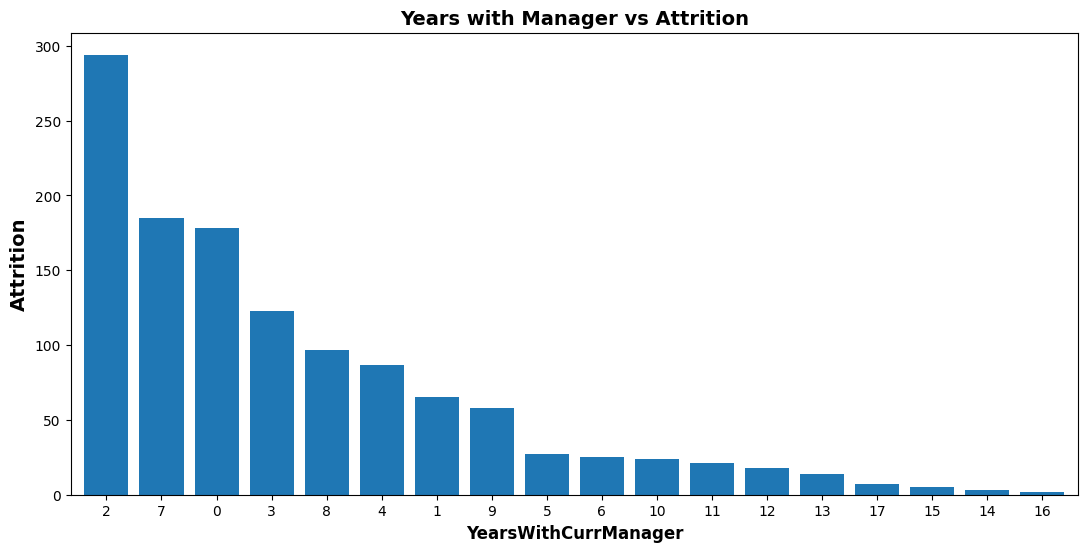

In [43]:
plt.figure(figsize=(10,8))
manegers.plot(kind='bar',width=0.8,figsize=(13,6))
plt.title("Years with Manager vs Attrition",fontsize=14, fontweight='bold')
plt.xlabel("YearsWithCurrManager",fontsize=12,fontweight='bold')
plt.ylabel("Attrition", fontsize=14,fontweight='bold')
plt.xticks(rotation=0)
plt.show()

In [44]:
maneger=df.groupby("Attrition")["YearsWithCurrManager"].mean()
#كلما زاد عدد سنين العمل مع نفس المدير تزيد نسبة الاستمرار في العمل
#المديرين ليسوا سبب واضح في استقالة الموظفين
manegers

,count
YearsWithCurrManager,
2,294
7,185
0,178
3,123
8,97
4,87
1,65
9,58
5,27


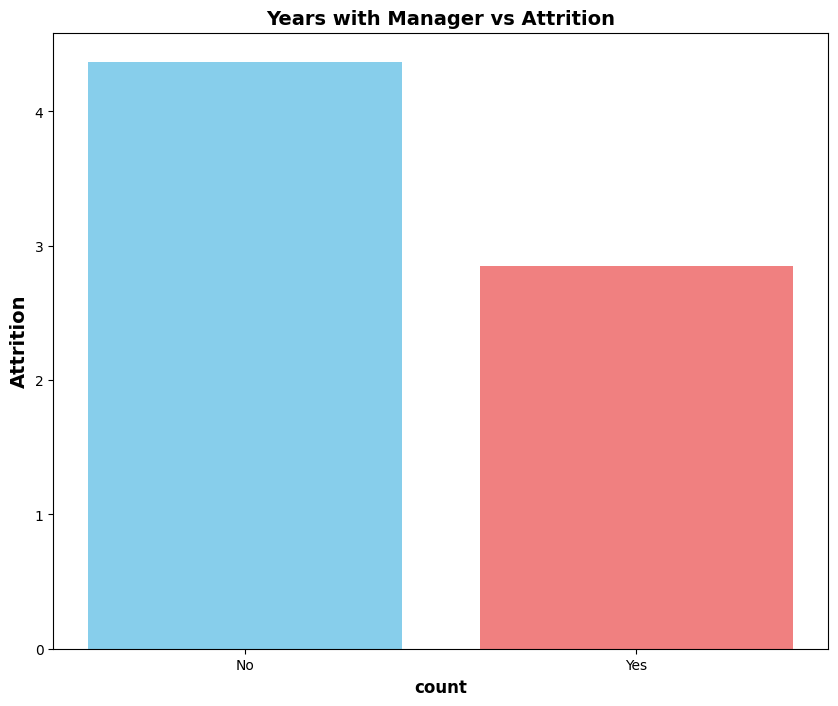

In [45]:
plt.figure(figsize=(10, 8))
plt.bar(maneger.index, maneger.values, color=['skyblue', 'lightcoral'])
plt.title("Years with Manager vs Attrition", fontsize=14, fontweight='bold')
plt.xlabel("count", fontsize=12, fontweight='bold')
plt.ylabel("Attrition", fontsize=14, fontweight='bold')
plt.show()


#12- what business value does the model bring ?

In [46]:
#يضيف هذا النموذج قيمة من حيث معرفة الاسباب المؤدية الى الاستقاله و ترك العمل
#كما يساعد معرفة اكثر الاقسام المتضرره و المتسببه في الاستقاله من حيث عدد الموظفين المستقالين
#و هذا من شأنه ان يساعد في توقع الاستقالات المستقبليه و العمل على تفادي الاخطاء المتسببه في الاستقالات و العمل على تحسين تلك الاخطاء لضمان عدم تكرارها

#13- Will the model save lots of money?

In [47]:
#من المؤكد ان العمل على تجنب الاخطاء و المشاكل التي تسبب الاستقالات يساعد على الحفاظ على الموظفين و الاستفادة من خبراتهم المكتسبة
#و بالتالي عدم تعيين موظفين آخرين و تدريبهم من البداية و اضاعة مزيد من الوقت


#14- Which business unit faces the attrition problem?

In [48]:
#اكثر وحدات التي تواجه مشكلة الاستقالاات هي :
#1-الاعمار الصغيرة و الشباب من الموظفين الذين ليس لديهم سنوات خبره كافيه بالشركة يقومون بالاستقاله بالمقارنه بالموظفين اصحاب الخبره و الاعمار الاكبر
#2-  قسم البحث و التطوير اكثر قسم استقال منه موظفين
#3- عدم الرضا عن بيئة العمل من اهم المشكلات المسببه للاستقالات
#4- الراتب و الزياده في المرتبات لها تأثير قوي على ترك الموظفين الشباب للعمل

#15- What role does gender and age play in this workplace?

In [49]:
gender_attrition = df.groupby(['Gender', 'Attrition']).size().unstack()
gender_attrition

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


<Figure size 1000x600 with 0 Axes>

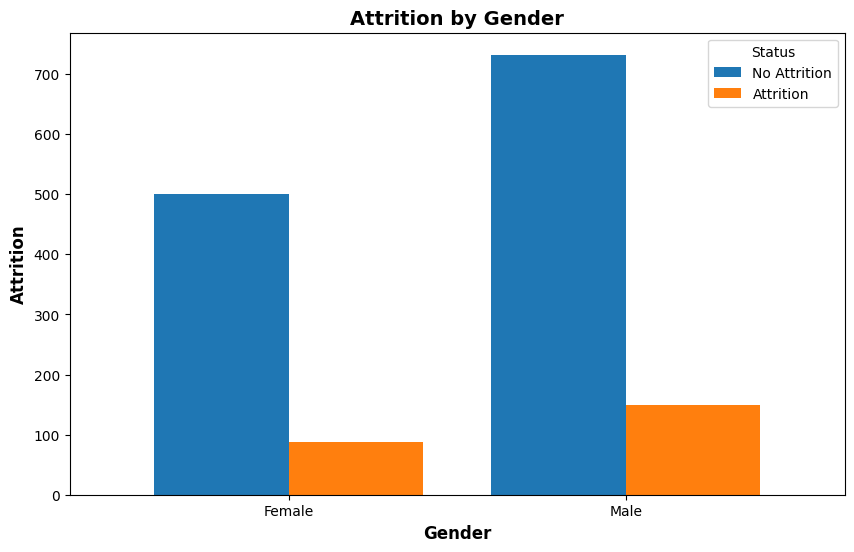

In [50]:
plt.figure(figsize=(10, 6))
gender_attrition.plot(kind='bar', width=0.8, figsize=(10, 6))
plt.title('Attrition by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12,fontweight='bold')
plt.ylabel('Attrition', fontsize=12,fontweight='bold')
plt.legend(['No Attrition', 'Attrition'], title='Status')
plt.xticks(rotation=0)
plt.show()

#16- How much does income matter?


In [51]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [52]:
df.groupby('Attrition')['MonthlyIncome'].mean()
#كلما زاد الدخل زاد الاستقرار الوظيفي و كلما قل الدخل زادت الاستقاله

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


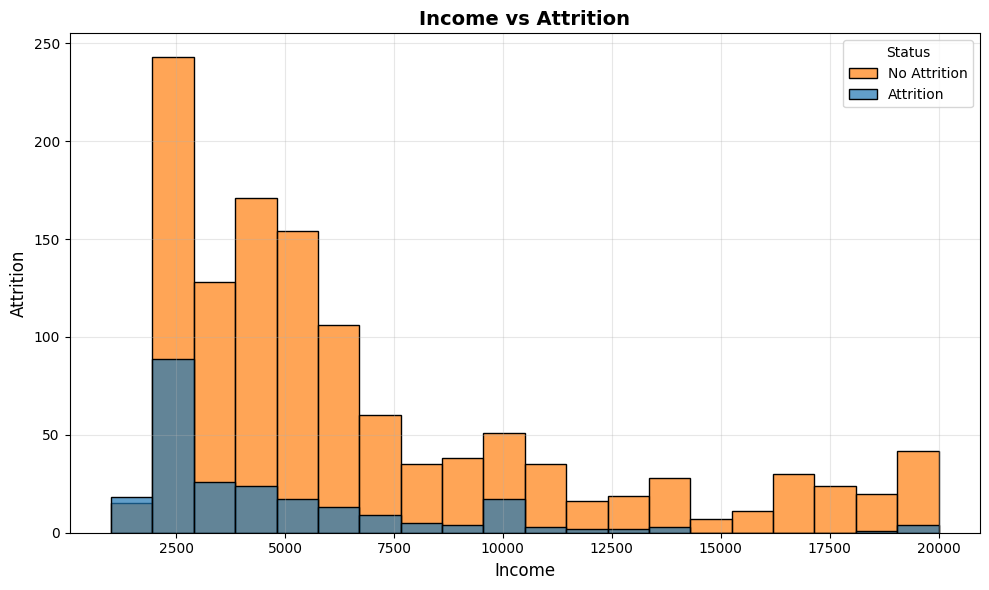

In [53]:
plt.figure(figsize=(10, 6))
sns.histplot(df,x='MonthlyIncome',hue='Attrition',bins=20,color=['skyblue','lightgreen'], alpha=0.7, edgecolor='black')
plt.title('Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Income', fontsize=12)
plt.ylabel('Attrition', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(['No Attrition', 'Attrition'], title='Status')
plt.tight_layout()
plt.show()


#17- Are more educated people more likely to leave?

In [54]:
df.groupby('Attrition')['Education'].mean()
#لا يوجد تأثير واضح و مؤثر من المستوى التعليمي على الاستقالة او الاستمرار في العمل

,Education
Attrition,
No,2.927007
Yes,2.839662


In [55]:
df.groupby(['Education', 'Attrition']).size().unstack()


Attrition,No,Yes
Education,,
1,139,31
2,238,44
3,473,99
4,340,58
5,43,5


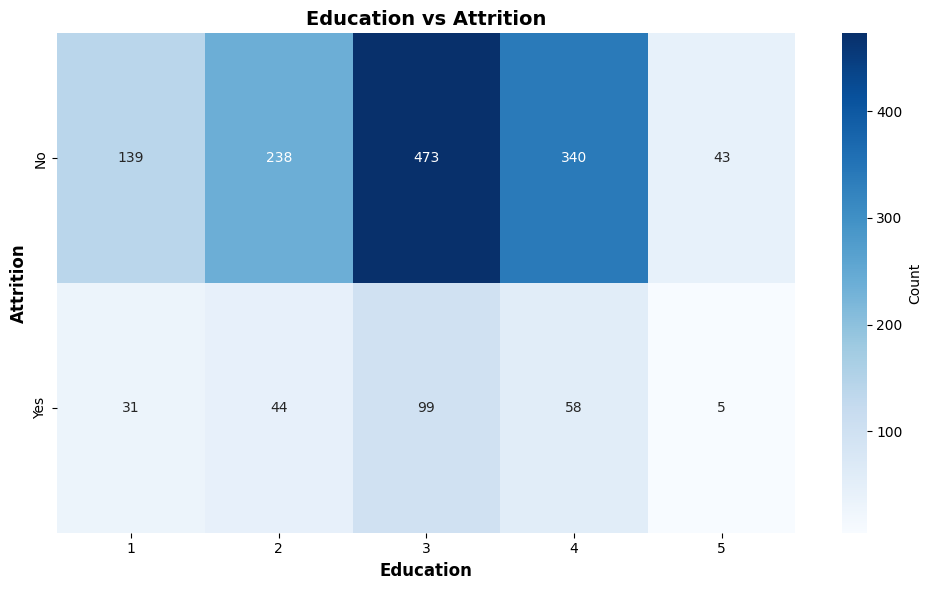

In [56]:
attrition_by_education = pd.crosstab(df['Attrition'],df['Education'])
plt.figure(figsize=(10, 6))
sns.heatmap(attrition_by_education, annot=True, cmap='Blues', fmt='d', cbar_kws={'label': 'Count'})
plt.title('Education vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Education', fontsize=12,fontweight='bold')
plt.ylabel('Attrition', fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()
